In [1]:
import string
from unet1 import UNet
from testing_functions import *
from torchmetrics.image import StructuralSimilarityIndexMeasure
from testing_model import LightningModel
import warnings
from helper_functions import *
import matplotlib.pyplot as plt
import torch
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

ssim = StructuralSimilarityIndexMeasure(data_range=1.0)

hparams = {
    "batch_size": 32,
    "learning_rate": 1e-4,
    "nb_levels": 4,
    "nb_inner_channels": 32,
    "nb_conv_layers_per_stage": 2,
    "data_slice_only": True,
    "max_epochs": 250,
}

In [2]:
warnings.filterwarnings('ignore')
dataset_semi = '../Datasets/OADAT/swfd/SWFD_semicircle_RawBP-mini.h5'
input_semi =  'sc,ss32_BP'
output_semi = 'sc_BP'

dataset_SCD = '../Datasets/OADAT/scd/SCD_RawBP-mini.h5'
# input =  'vc,ss32_BP'
# output = 'vc_BP'
input_SCD ='ms,ss32_BP'
output_SCD = "ms_BP"
dataset_multi = '../Datasets/OADAT/swfd/SWFD_multisegment_RawBP-mini.h5'
input_multi =  'ms,ss32_BP'
output_multi = 'ms_BP'

dataset_MSFD = '../Datasets/OADAT/msfd/MSFD_multisegment_RawBP-mini.h5'
input_MSFD =  'ms,ss32_BP_w780'
output_MSFD = 'ms_BP_w780'

In [3]:
# PAOmniNet Alpha models
path_PAOmniNet_alpha_Generalized = 'weights/PAOmni/OADAT/Alpha/PA_OmniNet_Generalized.ckpt'
path_PAOmniNet_alpha_MSFD = 'weights/PAOmni/OADAT/Alpha/PA_OmniNet_MSFD.ckpt'
path_PAOmniNet_alpha_Multi = 'weights/PAOmni/OADAT/Alpha/PA_OmniNet_Multi.ckpt'
path_PAOmniNet_alpha_SCD = 'weights/PAOmni/OADAT/Alpha/PA_OmniNet_SCD.ckpt'

# PAOmniNet MSE models
path_PAOmniNet_mse_Generalized = 'weights/PAOmni/OADAT/MSE/PA_OmniNet_Generalized.pth'
path_PAOmniNet_mse_MSFD = 'weights/PAOmni/OADAT/MSE/PA_OmniNet_MSFD.pth'
path_PAOmniNet_mse_Multi = 'weights/PAOmni/OADAT/MSE/PA_OmniNet_Multi.pth'
path_PAOmniNet_mse_SCD = 'weights/PAOmni/OADAT/MSE/PA_OmniNet_SCD.pth'

# PAOmniNet SSIM models
path_PAOmniNet_ssim_Generalized = 'weights/PAOmni/OADAT/SSIM/PA_OmniNet_Generalized.ckpt'
path_PAOmniNet_ssim_MSFD = 'weights/PAOmni/OADAT/SSIM/PA_OmniNet_MSFD.ckpt'
path_PAOmniNet_ssim_Multi = 'weights/PAOmni/OADAT/SSIM/PA_OmniNet_Multi.ckpt'
path_PAOmniNet_ssim_SCD = 'weights/PAOmni/OADAT/SSIM/PA_OmniNet_SCD.ckpt'

# Unet Alpha models
path_Unet_alpha_Generalized = 'weights/Unet/OADAT/Alpha/Unet_Generalized.pth'
path_Unet_alpha_MSFD = 'weights/Unet/OADAT/Alpha/Unet_MSFD.pth'
path_Unet_alpha_Multi = 'weights/Unet/OADAT/Alpha/Unet_Multi.pth'
path_Unet_alpha_SCD = 'weights/Unet/OADAT/Alpha/Unet_SCD.pth'

# Unet MSE models
path_Unet_mse_Generalized = 'weights/Unet/OADAT/MSE/Unet_Generalized.pth'
path_Unet_mse_MSFD = 'weights/Unet/OADAT/MSE/Unet_MSFD.pth'
path_Unet_mse_Multi = 'weights/Unet/OADAT/MSE/Unet_Multi.pth'
path_Unet_mse_SCD = 'weights/Unet/OADAT/MSE/Unet_SCD.pth'

# Unet SSIM models
path_Unet_ssim_Generalized = 'weights/Unet/OADAT/SSIM/Unet_Generalized.pth'
path_Unet_ssim_MSFD = 'weights/Unet/OADAT/SSIM/Unet_MSFD.pth'
path_Unet_ssim_Multi = 'weights/Unet/OADAT/SSIM/Unet_Multi.pth'
path_Unet_ssim_SCD = 'weights/Unet/OADAT/SSIM/Unet_SCD.pth'

# Load PAOmniNet Alpha models
PAOmniNet_alpha_Generalized = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_alpha_Generalized, map_location=torch.device('cpu'))
PAOmniNet_alpha_MSFD = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_alpha_MSFD, map_location=torch.device('cpu'))
PAOmniNet_alpha_Multi = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_alpha_Multi, map_location=torch.device('cpu'))
PAOmniNet_alpha_SCD = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_alpha_SCD, map_location=torch.device('cpu'))

# Load PAOmniNet MSE models
PAOmniNet_mse_Generalized = LightningModel(hparams)
state_dict = torch.load(path_PAOmniNet_mse_Generalized, map_location=torch.device('cpu'))
PAOmniNet_mse_Generalized.load_state_dict(state_dict)

PAOmniNet_mse_MSFD = LightningModel(hparams)
state_dict = torch.load(path_PAOmniNet_mse_MSFD, map_location=torch.device('cpu'))
PAOmniNet_mse_MSFD.load_state_dict(state_dict)

PAOmniNet_mse_Multi = LightningModel(hparams)
state_dict = torch.load(path_PAOmniNet_mse_Multi, map_location=torch.device('cpu'))
PAOmniNet_mse_Multi.load_state_dict(state_dict)

PAOmniNet_mse_SCD = LightningModel(hparams)
state_dict = torch.load(path_PAOmniNet_mse_SCD, map_location=torch.device('cpu'))
PAOmniNet_mse_SCD.load_state_dict(state_dict)

# Load PAOmniNet SSIM models
PAOmniNet_ssim_Generalized = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_ssim_Generalized, map_location=torch.device('cpu'))
PAOmniNet_ssim_MSFD = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_ssim_MSFD, map_location=torch.device('cpu'))
PAOmniNet_ssim_Multi = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_ssim_Multi, map_location=torch.device('cpu'))
PAOmniNet_ssim_SCD = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_ssim_SCD, map_location=torch.device('cpu'))

# Load Unet Alpha models
Unet_alpha_Generalized = UNet()
Unet_alpha_Generalized.load_state_dict(torch.load(path_Unet_alpha_Generalized, map_location=torch.device('cpu')))
Unet_alpha_Generalized.eval()

Unet_alpha_MSFD = UNet()
Unet_alpha_MSFD.load_state_dict(torch.load(path_Unet_alpha_MSFD, map_location=torch.device('cpu')))
Unet_alpha_MSFD.eval()

Unet_alpha_Multi = UNet()
Unet_alpha_Multi.load_state_dict(torch.load(path_Unet_alpha_Multi, map_location=torch.device('cpu')))
Unet_alpha_Multi.eval()

Unet_alpha_SCD = UNet()
Unet_alpha_SCD.load_state_dict(torch.load(path_Unet_alpha_SCD, map_location=torch.device('cpu')))
Unet_alpha_SCD.eval()

# Load Unet MSE models
Unet_mse_Generalized = UNet()
Unet_mse_Generalized.load_state_dict(torch.load(path_Unet_mse_Generalized, map_location=torch.device('cpu')))
Unet_mse_Generalized.eval()

Unet_mse_MSFD = UNet()
Unet_mse_MSFD.load_state_dict(torch.load(path_Unet_mse_MSFD, map_location=torch.device('cpu')))
Unet_mse_MSFD.eval()

Unet_mse_Multi = UNet()
Unet_mse_Multi.load_state_dict(torch.load(path_Unet_mse_Multi, map_location=torch.device('cpu')))
Unet_mse_Multi.eval()

Unet_mse_SCD = UNet()
Unet_mse_SCD.load_state_dict(torch.load(path_Unet_mse_SCD, map_location=torch.device('cpu')))
Unet_mse_SCD.eval()

# Load Unet SSIM models
Unet_ssim_Generalized = UNet()
Unet_ssim_Generalized.load_state_dict(torch.load(path_Unet_ssim_Generalized, map_location=torch.device('cpu')))
Unet_ssim_Generalized.eval()

Unet_ssim_MSFD = UNet()
Unet_ssim_MSFD.load_state_dict(torch.load(path_Unet_ssim_MSFD, map_location=torch.device('cpu')))
Unet_ssim_MSFD.eval()

Unet_ssim_Multi = UNet()
Unet_ssim_Multi.load_state_dict(torch.load(path_Unet_ssim_Multi, map_location=torch.device('cpu')))
Unet_ssim_Multi.eval()

Unet_ssim_SCD = UNet()
Unet_ssim_SCD.load_state_dict(torch.load(path_Unet_ssim_SCD, map_location=torch.device('cpu')))
Unet_ssim_SCD.eval()

print('All models have loaded!')

All models have loaded!


In [4]:
def preprocess_Unet(image, size=(256, 256)):
    image = (image - image.min()) / (image.max() - image.min())
    image = torch.tensor(image)
    image = image.unsqueeze(0)
    return image

def preprocess_batch_Unet(images, size=(256, 256)):
    processed_images = []
    for image in images:
        processed_image = preprocess_Unet(image, size)
        processed_images.append(processed_image)
    return torch.cat(processed_images, dim=0)

def get_all_test_data(dataset:str, input, output, CONTEXT_SIZE=16, idx_i=0):
    X, y = data_loader_formatter(dataset, input, output)
    X, y, context_in, context_out = creating_context(X, y, idx=idx_i, context_size = CONTEXT_SIZE, random=False)
    X_Neuralizer = preprocess(X)
    y_Neuralizer = preprocess(y)
    X_Unet = preprocess_Unet(X)
    y_Unet = preprocess_Unet(y)
    context_in_preprocessed, context_out_preprocessed = preprocess_context(context_in, context_out)
    print(f'In this order:\nX_test_Neur = {X_Neuralizer.shape}, y_test_Neur = {y_Neuralizer.shape}, X_context = {context_in_preprocessed.shape}, y_context = {context_out_preprocessed.shape}\n'
          f'X_test_Unet = {X_Unet.shape}, y_test_Unet = {y_Unet.shape}')
    return X_Neuralizer, y_Neuralizer, context_in_preprocessed, context_out_preprocessed, X_Unet, y_Unet

In [5]:
def get_row(X_Neuralizer, y_Neuralizer, context_in, context_out, X_Unet, y_Unet, Neur_Generalized, Unet_Generalized, Neur_specific, Unet_specific):
    input_Unet = X_Unet
    input_Unet = input_Unet.float()
    input_Unet = input_Unet.unsqueeze(0)
    input_Unet = input_Unet.unsqueeze(0)
    input_Neur = X_Neuralizer.unsqueeze(0)

    ground_truth_Unet = y_Unet
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Neur = y_Neuralizer.unsqueeze(0)

    output_Neur_Semi = Neur_Generalized.forward(input_Neur, context_in, context_out)
    output_Neur_Semi =(output_Neur_Semi - output_Neur_Semi.min()) / (output_Neur_Semi.max() - output_Neur_Semi.min())

    output_Neur_specific = Neur_specific.forward(input_Neur, context_in, context_out)
    output_Neur_specific = (output_Neur_specific - output_Neur_specific.min()) / (output_Neur_specific.max() - output_Neur_specific.min())

    output_Unet_Semi = Unet_Generalized(input_Unet.squeeze(0))
    output_Unet_Semi = (output_Unet_Semi - output_Unet_Semi.min()) / (output_Unet_Semi.max() - output_Unet_Semi.min())

    output_Unet_specific = Unet_specific(input_Unet.squeeze(0))
    output_Unet_specific = (output_Unet_specific - output_Unet_specific.min()) / (output_Unet_specific.max() - output_Unet_specific.min())

    rmse_base = compute_rmse(ground_truth_Neur, input_Neur)
    psnr_base = compute_psnr(ground_truth_Neur, input_Neur)
    ssim_base = ssim(ground_truth_Neur.squeeze(1), input_Neur.squeeze(1)).item()
    baseline_metrics = [rmse_base, psnr_base, ssim_base]

    rmse_neur_semi = compute_rmse(ground_truth_Neur.squeeze(0), output_Neur_Semi.squeeze(0))
    psnr_neur_semi = compute_psnr(ground_truth_Neur.squeeze(0), output_Neur_Semi.squeeze(0))
    ssim_neur_semi = ssim(ground_truth_Neur.squeeze(1), output_Neur_Semi).item()
    PA_generalized_metrics = [rmse_neur_semi, psnr_neur_semi, ssim_neur_semi]

    rmse_neur_specific = compute_rmse(ground_truth_Neur.squeeze(0), output_Neur_specific.squeeze(0))
    psnr_neur_specific = compute_psnr(ground_truth_Neur.squeeze(0), output_Neur_specific.squeeze(0))
    ssim_neur_specific = ssim(ground_truth_Neur.squeeze(1), output_Neur_specific).item()
    PA_specific_metrics = [rmse_neur_specific, psnr_neur_specific, ssim_neur_specific]

    rmse_unet_semi = compute_rmse(ground_truth_Unet, output_Unet_Semi)
    psnr_unet_semi = compute_psnr(ground_truth_Unet, output_Unet_Semi)
    ssim_unet_semi = ssim(ground_truth_Unet.squeeze(1), output_Unet_Semi).item()
    Unet_generalized_metrics = [rmse_unet_semi, psnr_unet_semi, ssim_unet_semi]

    rmse_unet_specific = compute_rmse(ground_truth_Unet, output_Unet_specific)
    psnr_unet_specific = compute_psnr(ground_truth_Unet, output_Unet_specific)
    ssim_unet_specific = ssim(ground_truth_Unet.squeeze(1), output_Unet_specific).item()
    Unet_specific_metrics = [rmse_unet_specific, psnr_unet_specific, ssim_unet_specific]

    input_img = input_Unet.squeeze().cpu().detach().numpy()
    PA_generalized_img = output_Neur_Semi.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    PA_specific_img = output_Neur_specific.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    Unet_generalized_img = output_Unet_Semi.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    Unet_specific_img = output_Unet_specific.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
    output_img = ground_truth_Unet.squeeze().cpu().detach().numpy()
    return input_img, Unet_generalized_img, Unet_specific_img, PA_generalized_img, PA_specific_img, output_img, [baseline_metrics, Unet_generalized_metrics, Unet_specific_metrics, PA_generalized_metrics, PA_specific_metrics]

In [6]:
idx = 3
X_Neuralizer_Semi, y_Neuralizer_Semi, X_context_Semi, y_context_Semi, X_unet_Semi, y_unet_Semi = get_all_test_data(dataset_semi, input_semi, output_semi, idx_i=idx)
X_Neuralizer_Multi, y_Neuralizer_Multi, X_context_Multi, y_context_Multi, X_unet_Multi, y_unet_Multi = get_all_test_data(dataset_multi, input_multi, output_multi, idx_i=14) #144
X_Neuralizer_SCD, y_Neuralizer_SCD, X_context_SCD, y_context_SCD, X_unet_SCD, y_unet_SCD = get_all_test_data(dataset_SCD, input_SCD, output_SCD, idx_i=6)
X_Neuralizer_MSFD, y_Neuralizer_MSFD, X_context_MSFD, y_context_MSFD, X_unet_MSFD, y_unet_MSFD = get_all_test_data(dataset_MSFD, input_MSFD, output_MSFD, idx_i=4)

# X_Neuralizer_Semi, y_Neuralizer_Semi, X_context_Semi, y_context_Semi, X_unet_Semi, y_unet_Semi = get_all_test_data(dataset_SCD, input_SCD, output_SCD, idx_i=60)
# X_Neuralizer_Multi, y_Neuralizer_Multi, X_context_Multi, y_context_Multi, X_unet_Multi, y_unet_Multi = get_all_test_data(dataset_SCD, input_SCD, output_SCD, idx_i=60)
# X_Neuralizer_SCD, y_Neuralizer_SCD, X_context_SCD, y_context_SCD, X_unet_SCD, y_unet_SCD = get_all_test_data(dataset_SCD, input_SCD, output_SCD, idx_i=60)
# X_Neuralizer_MSFD, y_Neuralizer_MSFD, X_context_MSFD, y_context_MSFD, X_unet_MSFD, y_unet_MSFD = get_all_test_data(dataset_SCD, input_SCD, output_SCD, idx_i=60)

In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 16, 3, 256, 256]), y_context = torch.Size([1, 16, 3, 256, 256])
X_test_Unet = torch.Size([1, 256, 256]), y_test_Unet = torch.Size([1, 256, 256])
In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 16, 3, 256, 256]), y_context = torch.Size([1, 16, 3, 256, 256])
X_test_Unet = torch.Size([1, 256, 256]), y_test_Unet = torch.Size([1, 256, 256])
In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 16, 3, 256, 256]), y_context = torch.Size([1, 16, 3, 256, 256])
X_test_Unet = torch.Size([1, 256, 256]), y_test_Unet = torch.Size([1, 256, 256])
In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 16, 3, 256, 256]), y_context = torch.Size([1,

In [9]:
def get_row_4(X_Neuralizer, y_Neuralizer, context_in, context_out, X_Unet, y_Unet, Neur_Generalized, Unet_Generalized):
    input_Unet = X_Unet
    input_Unet = input_Unet.float()
    input_Unet = input_Unet.unsqueeze(0)
    input_Unet = input_Unet.unsqueeze(0)
    input_Neur = X_Neuralizer.unsqueeze(0)

    ground_truth_Unet = y_Unet
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Neur = y_Neuralizer.unsqueeze(0)

    output_Neur_Semi = Neur_Generalized.forward(input_Neur, context_in, context_out)
    output_Neur_Semi =(output_Neur_Semi - output_Neur_Semi.min()) / (output_Neur_Semi.max() - output_Neur_Semi.min())

    output_Unet_Semi = Unet_Generalized(input_Unet.squeeze(0))
    output_Unet_Semi = (output_Unet_Semi - output_Unet_Semi.min()) / (output_Unet_Semi.max() - output_Unet_Semi.min())

    rmse_base = compute_rmse(ground_truth_Neur, input_Neur)
    psnr_base = compute_psnr(ground_truth_Neur, input_Neur)
    ssim_base = ssim(ground_truth_Neur.squeeze(1), input_Neur.squeeze(1)).item()
    baseline_metrics = [rmse_base, psnr_base, ssim_base]

    rmse_neur_semi = compute_rmse(ground_truth_Neur.squeeze(0), output_Neur_Semi.squeeze(0))
    psnr_neur_semi = compute_psnr(ground_truth_Neur.squeeze(0), output_Neur_Semi.squeeze(0))
    ssim_neur_semi = ssim(ground_truth_Neur.squeeze(1), output_Neur_Semi).item()
    PA_generalized_metrics = [rmse_neur_semi, psnr_neur_semi, ssim_neur_semi]


    rmse_unet_semi = compute_rmse(ground_truth_Unet, output_Unet_Semi)
    psnr_unet_semi = compute_psnr(ground_truth_Unet, output_Unet_Semi)
    ssim_unet_semi = ssim(ground_truth_Unet.squeeze(1), output_Unet_Semi).item()
    Unet_generalized_metrics = [rmse_unet_semi, psnr_unet_semi, ssim_unet_semi]


    input_img = input_Unet.squeeze().cpu().detach().numpy()
    PA_generalized_img = output_Neur_Semi.squeeze().permute(1, 2, 0).cpu().detach().numpy()

    Unet_generalized_img = output_Unet_Semi.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

    output_img = ground_truth_Unet.squeeze().cpu().detach().numpy()
    return input_img, Unet_generalized_img, PA_generalized_img, output_img, [baseline_metrics, Unet_generalized_metrics, PA_generalized_metrics]

<Figure size 34000x18000 with 0 Axes>

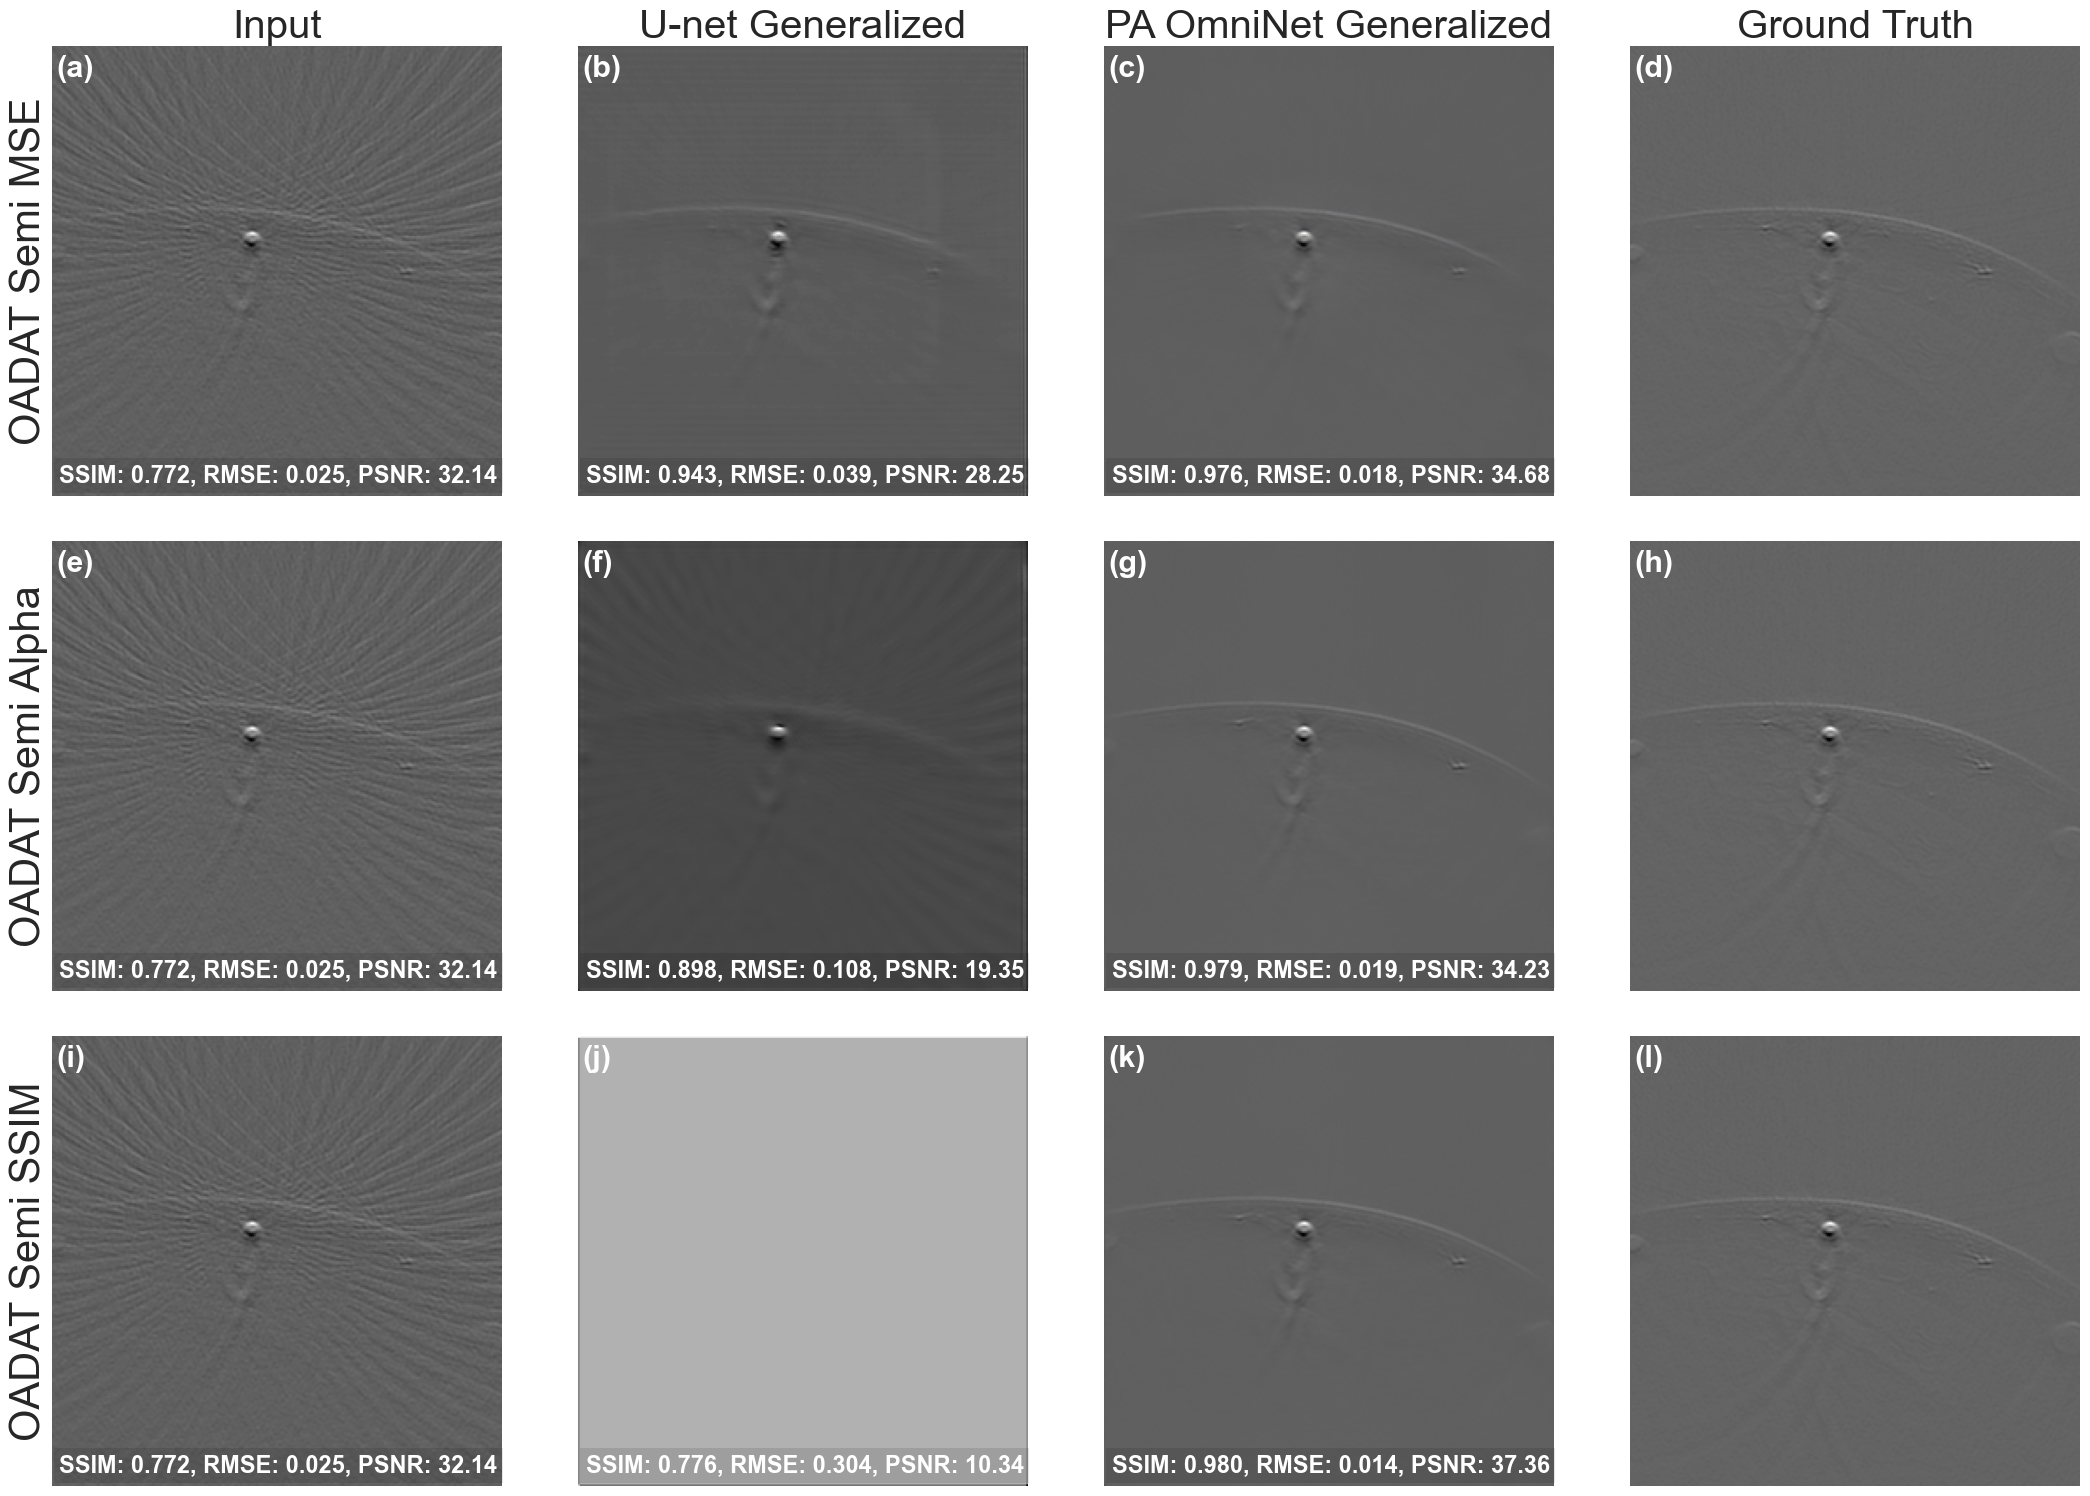

In [23]:

input_img_multi, Unet_generalized_img_multi, PA_generalized_img_multi, output_img_multi, [baseline_metrics_multi, Unet_generalized_metrics_multi, PA_generalized_metrics_multi] =(
    get_row_4(X_Neuralizer_Semi, y_Neuralizer_Semi, X_context_Semi, y_context_Semi, X_unet_Semi, y_unet_Semi, PAOmniNet_mse_Generalized, Unet_mse_Generalized))

input_img_MSFD, Unet_generalized_img_MSFD, PA_generalized_img_MSFD, output_img_MSFD, [baseline_metrics_MSFD, Unet_generalized_metrics_MSFD, PA_generalized_metrics_MSFD] =(
    get_row_4(X_Neuralizer_Semi, y_Neuralizer_Semi, X_context_Semi, y_context_Semi, X_unet_Semi, y_unet_Semi, PAOmniNet_alpha_Generalized, Unet_alpha_Generalized))

input_img_SCD, Unet_generalized_img_SCD, PA_generalized_img_SCD, output_img_SCD, [baseline_metrics_SCD, Unet_generalized_metrics_SCD, PA_generalized_metrics_SCD] =(
    get_row_4(X_Neuralizer_Semi, y_Neuralizer_Semi, X_context_Semi, y_context_Semi, X_unet_Semi, y_unet_Semi, PAOmniNet_ssim_Generalized, Unet_ssim_Generalized))
titles = ['Input', 'U-net Generalized', 'PA OmniNet Generalized', 'Ground Truth']
images = [input_img_multi, Unet_generalized_img_multi, PA_generalized_img_multi, output_img_multi,
          input_img_MSFD, Unet_generalized_img_MSFD, PA_generalized_img_MSFD, output_img_MSFD,
          input_img_SCD, Unet_generalized_img_SCD, PA_generalized_img_SCD, output_img_SCD]

plt.figure(figsize=(34, 18), dpi=1000)

metrics = [
    f"SSIM: {baseline_metrics_multi[2]:.3f}, RMSE: {baseline_metrics_multi[0]:.3f}, PSNR: {baseline_metrics_multi[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_multi[2]:.3f}, RMSE: {Unet_generalized_metrics_multi[0]:.3f}, PSNR: {Unet_generalized_metrics_multi[1]:.2f}",

    f"SSIM: {PA_generalized_metrics_multi[2]:.3f}, RMSE: {PA_generalized_metrics_multi[0]:.3f}, PSNR: {PA_generalized_metrics_multi[1]:.2f}",

    "Ground Truth",

    f"SSIM: {baseline_metrics_MSFD[2]:.3f}, RMSE: {baseline_metrics_MSFD[0]:.3f}, PSNR: {baseline_metrics_MSFD[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_MSFD[2]:.3f}, RMSE: {Unet_generalized_metrics_MSFD[0]:.3f}, PSNR: {Unet_generalized_metrics_MSFD[1]:.2f}",

    f"SSIM: {PA_generalized_metrics_MSFD[2]:.3f}, RMSE: {PA_generalized_metrics_MSFD[0]:.3f}, PSNR: {PA_generalized_metrics_MSFD[1]:.2f}",

    "Ground Truth",

    f"SSIM: {baseline_metrics_SCD[2]:.3f}, RMSE: {baseline_metrics_SCD[0]:.3f}, PSNR: {baseline_metrics_SCD[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_SCD[2]:.3f}, RMSE: {Unet_generalized_metrics_SCD[0]:.3f}, PSNR: {Unet_generalized_metrics_SCD[1]:.2f}",

    f"SSIM: {PA_generalized_metrics_SCD[2]:.3f}, RMSE: {PA_generalized_metrics_SCD[0]:.3f}, PSNR: {PA_generalized_metrics_SCD[1]:.2f}",

    "Ground Truth",
]

plt.figure(figsize=(34, 18))

alphabet = string.ascii_lowercase[:len(images)]
for idx, (img, metric, letter) in enumerate(zip(images, metrics, alphabet)):
    ax = plt.subplot(3,4, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    ax.text(0.01, 0.95, f"({letter})", fontsize=22, va='center', ha='left', color='white', fontweight='bold', transform=ax.transAxes)

    # Add row labels
    if idx % 4 == 0:
        # row_label = ['SWFD Multi', 'MSFD', 'SCD'][idx // 6]
        row_label = ['OADAT Semi MSE', 'OADAT Semi Alpha', 'OADAT Semi SSIM'][idx // 4]
        ax.text(-.05, 0.5, row_label, fontsize=30, va='center', ha='center', rotation='vertical', transform=ax.transAxes)

    # Add titles only for the first row
    if idx < 4:
        plt.title(titles[idx], fontsize=29)

    # Add metrics for non-Ground Truth images
    if metric != "Ground Truth":
        ax.text(0.017, 0.02, metric, fontsize=17, color="white",
                bbox=dict(facecolor='black', alpha=0.1, edgecolor='none'),
                va="bottom", ha="left", transform=ax.transAxes,  fontweight='bold')

plt.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.1, wspace=-.7, hspace=0.1)
plt.show()


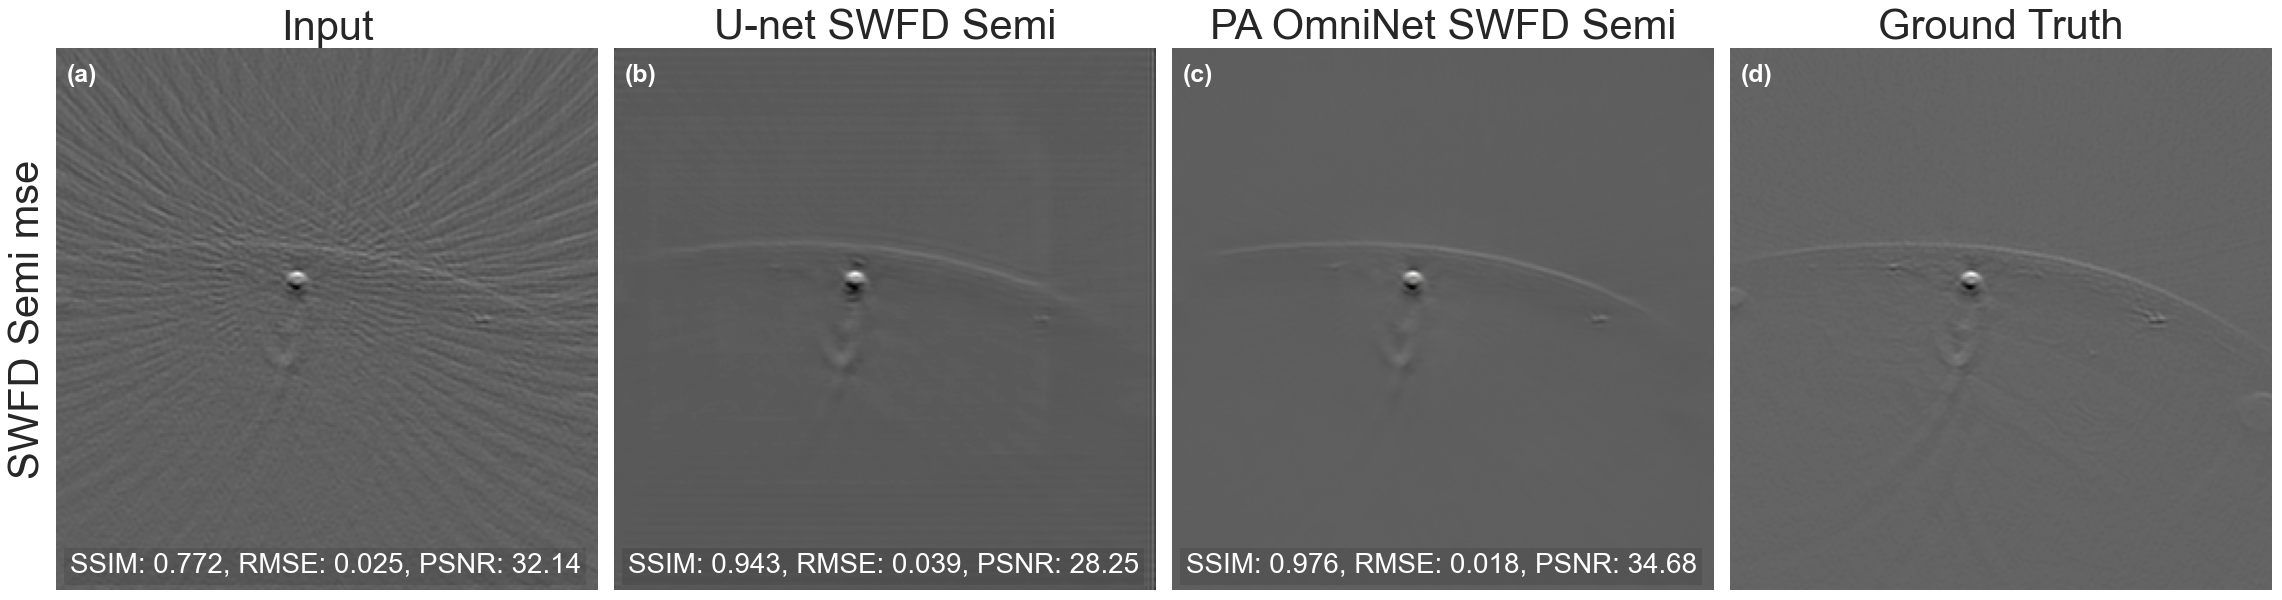

In [7]:
input_Unet = X_unet_Semi
input_Unet = input_Unet.float()
input_Unet = input_Unet.unsqueeze(0)
input_Unet = input_Unet.unsqueeze(0)
input_Neur = X_Neuralizer_Semi.unsqueeze(0)

ground_truth_Unet = y_unet_Semi
ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
ground_truth_Neur = y_Neuralizer_Semi.unsqueeze(0)

output_Neur_Semi = PAOmniNet_mse_Generalized.forward(input_Neur, X_context_Semi, y_context_Semi)
output_Neur_Semi =(output_Neur_Semi - output_Neur_Semi.min()) / (output_Neur_Semi.max() - output_Neur_Semi.min())
output_Unet_Semi =  Unet_mse_Generalized(input_Unet.squeeze(0))
output_Unet_Semi = (output_Unet_Semi - output_Unet_Semi.min()) / (output_Unet_Semi.max() - output_Unet_Semi.min())

rmse_base_semi = compute_rmse(ground_truth_Neur, input_Neur)
psnr_base_semi = compute_psnr(ground_truth_Neur, input_Neur)
ssim_base_semi = ssim(ground_truth_Neur.squeeze(1), input_Neur.squeeze(1)).item()

rmse_neur_semi = compute_rmse(ground_truth_Neur.squeeze(0), output_Neur_Semi.squeeze(0))
psnr_neur_semi = compute_psnr(ground_truth_Neur.squeeze(0), output_Neur_Semi.squeeze(0))
ssim_neur_semi = ssim(ground_truth_Neur.squeeze(1), output_Neur_Semi).item()

rmse_unet_semi = compute_rmse(ground_truth_Unet, output_Unet_Semi)
psnr_unet_semi = compute_psnr(ground_truth_Unet, output_Unet_Semi)
ssim_unet_semi = ssim(ground_truth_Unet.squeeze(1), output_Unet_Semi).item()

input_show_semi = input_Unet.squeeze().cpu().detach().numpy()
output_show_semi = ground_truth_Unet.squeeze().cpu().detach().numpy()
outputimg_Neur_Semi = output_Neur_Semi.squeeze().permute(1, 2, 0).cpu().detach().numpy()
outputimg_Unet_Semi = output_Unet_Semi.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
titles = [
    f'Input',
    f'U-net SWFD Semi',f'PA OmniNet SWFD Semi',
    'Ground Truth']
images = [input_show_semi,outputimg_Unet_Semi, outputimg_Neur_Semi, output_show_semi]

plt.figure(figsize=(34, 12) )

# List of corresponding metrics for each image
metrics = [
    f"SSIM: {ssim_base_semi:.3f}, RMSE: {rmse_base_semi:.3f}, PSNR: {psnr_base_semi:.2f}",
    f"SSIM: {ssim_unet_semi:.3f}, RMSE: {rmse_unet_semi:.3f}, PSNR: {psnr_unet_semi:.2f}",
#     f"SSIM: {ssim_specific:.3f}, RMSE: {rmse_specific:.3f}, PSNR: {psnr_specific:.2f}",
    f"SSIM: {ssim_neur_semi:.3f}, RMSE: {rmse_neur_semi:.3f}, PSNR: {psnr_neur_semi:.2f}",
#     f"SSIM: {ssim_val_neur_specific:.3f}, RMSE: {rmse_val_neur_specific:.3f}, PSNR: {psnr_val_neur_specific:.2f}",
    "Ground Truth",  # No metrics for Ground Truth
]
alphabet = string.ascii_lowercase[:len(images)]
for idx, (title, img, metric, letter) in enumerate(zip(titles, images, metrics, alphabet)):
    ax = plt.subplot(1, 6, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    ax.text(0.02, 0.95, f"({letter})", fontsize=18, va='center', ha='left', color='white', fontweight='bold', transform=ax.transAxes)
    if idx == 0:
        ax.text(-.05, 0.5, 'SWFD Semi mse', fontsize=30, va='center', ha='center', rotation='vertical', transform=ax.transAxes)


    if idx < 6:
        plt.title(title, fontsize=30)

    if idx < len(metrics) and metrics[idx] != "Ground Truth":
        ax.text(0.025, 0.02, metrics[idx], fontsize=20, color="white",
                bbox=dict(facecolor='black', alpha=0.1, edgecolor='none'),
                va="bottom", ha="left", transform=ax.transAxes)

plt.subplots_adjust(left=0.01, right=0.99, top=0.85, bottom=0.15, wspace=0.03, hspace=0.03)
plt.show()



In [33]:

input_img_multi, Unet_generalized_img_multi, Unet_specific_img_multi, PA_generalized_img_multi, PA_specific_img_multi, output_img_multi, [baseline_metrics_multi, Unet_generalized_metrics_multi, Unet_specific_metrics_multi, PA_generalized_metrics_multi, PA_specific_metrics_multi] =(
    get_row(X_Neuralizer_Multi, y_Neuralizer_Multi, X_context_Multi, y_context_Multi, X_unet_Multi, y_unet_Multi, PAOmniNet_alpha_Generalized, Unet_mse_Generalized, PAOmniNet_alpha_Multi, Unet_mse_Multi))

input_img_MSFD, Unet_generalized_img_MSFD, Unet_specific_img_MSFD, PA_generalized_img_MSFD, PA_specific_img_MSFD, output_img_MSFD, [baseline_metrics_MSFD, Unet_generalized_metrics_MSFD, Unet_specific_metrics_MSFD, PA_generalized_metrics_MSFD, PA_specific_metrics_MSFD] =(
    get_row(X_Neuralizer_MSFD, y_Neuralizer_MSFD, X_context_MSFD, y_context_MSFD, X_unet_MSFD, y_unet_MSFD, PAOmniNet_alpha_Generalized, Unet_mse_Generalized, PAOmniNet_alpha_MSFD, Unet_mse_MSFD))
input_img_SCD, Unet_generalized_img_SCD, Unet_specific_img_SCD, PA_generalized_img_SCD, PA_specific_img_SCD, output_img_SCD, [baseline_metrics_SCD, Unet_generalized_metrics_SCD, Unet_specific_metrics_SCD, PA_generalized_metrics_SCD, PA_specific_metrics_SCD] =(
    get_row(X_Neuralizer_SCD, y_Neuralizer_SCD, X_context_SCD, y_context_SCD, X_unet_SCD, y_unet_SCD, PAOmniNet_alpha_Generalized, Unet_mse_Generalized, PAOmniNet_alpha_SCD, Unet_mse_SCD))
titles = ['Input', 'U-net Generalized', 'U-net Specific', 'PA OmniNet Generalized', 'PA OmniNet Specific', 'Ground Truth']
images = [input_img_multi, Unet_generalized_img_multi, Unet_specific_img_multi, PA_generalized_img_multi, PA_specific_img_multi, output_img_multi,
          input_img_MSFD, Unet_generalized_img_MSFD, Unet_specific_img_MSFD, PA_generalized_img_MSFD, PA_specific_img_MSFD, output_img_MSFD,
          input_img_SCD, Unet_generalized_img_SCD, Unet_specific_img_SCD, PA_generalized_img_SCD, PA_specific_img_SCD, output_img_SCD]

plt.figure(figsize=(34, 18))

metrics = [
    f"SSIM: {baseline_metrics_multi[2]:.3f}, RMSE: {baseline_metrics_multi[0]:.3f}, PSNR: {baseline_metrics_multi[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_multi[2]:.3f}, RMSE: {Unet_generalized_metrics_multi[0]:.3f}, PSNR: {Unet_generalized_metrics_multi[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_multi[2]:.3f}, RMSE: {Unet_specific_metrics_multi[0]:.3f}, PSNR: {Unet_specific_metrics_multi[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_multi[2]:.3f}, RMSE: {PA_generalized_metrics_multi[0]:.3f}, PSNR: {PA_generalized_metrics_multi[1]:.2f}",
    f"SSIM: {PA_specific_metrics_multi[2]:.3f}, RMSE: {PA_specific_metrics_multi[0]:.3f}, PSNR: {PA_specific_metrics_multi[1]:.2f}",
    "Ground Truth",

    f"SSIM: {baseline_metrics_MSFD[2]:.3f}, RMSE: {baseline_metrics_MSFD[0]:.3f}, PSNR: {baseline_metrics_MSFD[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_MSFD[2]:.3f}, RMSE: {Unet_generalized_metrics_MSFD[0]:.3f}, PSNR: {Unet_generalized_metrics_MSFD[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_MSFD[2]:.3f}, RMSE: {Unet_specific_metrics_MSFD[0]:.3f}, PSNR: {Unet_specific_metrics_MSFD[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_MSFD[2]:.3f}, RMSE: {PA_generalized_metrics_MSFD[0]:.3f}, PSNR: {PA_generalized_metrics_MSFD[1]:.2f}",
    f"SSIM: {PA_specific_metrics_MSFD[2]:.3f}, RMSE: {PA_specific_metrics_MSFD[0]:.3f}, PSNR: {PA_specific_metrics_MSFD[1]:.2f}",
    "Ground Truth",

    f"SSIM: {baseline_metrics_SCD[2]:.3f}, RMSE: {baseline_metrics_SCD[0]:.3f}, PSNR: {baseline_metrics_SCD[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_SCD[2]:.3f}, RMSE: {Unet_generalized_metrics_SCD[0]:.3f}, PSNR: {Unet_generalized_metrics_SCD[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_SCD[2]:.3f}, RMSE: {Unet_specific_metrics_SCD[0]:.3f}, PSNR: {Unet_specific_metrics_SCD[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_SCD[2]:.3f}, RMSE: {PA_generalized_metrics_SCD[0]:.3f}, PSNR: {PA_generalized_metrics_SCD[1]:.2f}",
    f"SSIM: {PA_specific_metrics_SCD[2]:.3f}, RMSE: {PA_specific_metrics_SCD[0]:.3f}, PSNR: {PA_specific_metrics_SCD[1]:.2f}",
    "Ground Truth",
]

plt.figure(figsize=(34, 18), dpi=500)

alphabet = string.ascii_lowercase[:len(images)]
for idx, (img, metric, letter) in enumerate(zip(images, metrics, alphabet)):
    ax = plt.subplot(3, 6, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    ax.text(0.01, 0.95, f"({letter})", fontsize=22, va='center', ha='left', color='white', fontweight='bold', transform=ax.transAxes)

    # Add row labels
    if idx % 6 == 0:
        # row_label = ['SWFD Multi', 'MSFD', 'SCD'][idx // 6]
        row_label = ['OADAT Multi', 'OADAT MSFD', 'OADAT SCD'][idx // 6]
        ax.text(-.05, 0.5, row_label, fontsize=30, va='center', ha='center', rotation='vertical', transform=ax.transAxes)

    # Add titles only for the first row
    if idx < 6:
        plt.title(titles[idx], fontsize=29)

    # Add metrics for non-Ground Truth images
    if metric != "Ground Truth":
        ax.text(0.017, 0.02, metric, fontsize=17, color="white",
                bbox=dict(facecolor='black', alpha=0.1, edgecolor='none'),
                va="bottom", ha="left", transform=ax.transAxes,  fontweight='bold')

plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.01, hspace=0.1)
plt.show()


<Figure size 3400x1800 with 0 Axes>

In [25]:
X_Neuralizer_MSFD, y_Neuralizer_MSFD, X_context_MSFD_4, y_context_MSFD_4, X_unet_MSFD, y_unet_MSFD = get_all_test_data(dataset_MSFD, input_MSFD, output_MSFD, CONTEXT_SIZE=4, idx_i=24)
_, _, X_context_MSFD_8, y_context_MSFD_8, _, _ = get_all_test_data(dataset_MSFD, input_MSFD, output_MSFD, CONTEXT_SIZE=8, idx_i=24)
_, _, X_context_MSFD_16, y_context_MSFD_16, _, _ = get_all_test_data(dataset_MSFD, input_MSFD, output_MSFD, CONTEXT_SIZE=16, idx_i=24)
_, _, X_context_MSFD_32, y_context_MSFD_32, _, _ = get_all_test_data(dataset_MSFD, input_MSFD, output_MSFD, CONTEXT_SIZE=32, idx_i=24)

In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 4, 3, 256, 256]), y_context = torch.Size([1, 4, 3, 256, 256])
X_test_Unet = torch.Size([1, 256, 256]), y_test_Unet = torch.Size([1, 256, 256])
In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 8, 3, 256, 256]), y_context = torch.Size([1, 8, 3, 256, 256])
X_test_Unet = torch.Size([1, 256, 256]), y_test_Unet = torch.Size([1, 256, 256])
In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 16, 3, 256, 256]), y_context = torch.Size([1, 16, 3, 256, 256])
X_test_Unet = torch.Size([1, 256, 256]), y_test_Unet = torch.Size([1, 256, 256])
In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 32, 3, 256, 256]), y_context = torch.Size([1, 32,

In [26]:
import matplotlib.pyplot as plt
import string

def normalize(img):
    return (img - img.min()) / (img.max() - img.min())

# Process U-Net
input_Unet = X_unet_MSFD.unsqueeze(0).unsqueeze(0).float()
ground_truth_Unet = y_unet_MSFD.unsqueeze(0).unsqueeze(0)
output_Unet_MSFD = normalize(Unet_mse_Generalized(input_Unet.squeeze(0)))

rmse_unet = compute_rmse(ground_truth_Unet, output_Unet_MSFD)
psnr_unet = compute_psnr(ground_truth_Unet, output_Unet_MSFD)
ssim_unet = ssim(ground_truth_Unet.squeeze(1), output_Unet_MSFD).item()

# Process Neuralizer with different context sizes
context_sizes = [4, 8, 16, 32]
context_data = [(X_context_MSFD_4, y_context_MSFD_4),
                (X_context_MSFD_8, y_context_MSFD_8),
                (X_context_MSFD_16, y_context_MSFD_16),
                (X_context_MSFD_32, y_context_MSFD_32)]
input = X_Neuralizer_MSFD.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
outputs = [X_Neuralizer_MSFD.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()]
metrics = [f"SSIM: {ssim_unet:.3f}, RMSE: {rmse_unet:.3f}, PSNR: {psnr_unet:.2f}"]
titles = ["Input"]

for (X_context, y_context), size in zip(context_data, context_sizes):
    input_Neur = X_Neuralizer_MSFD.unsqueeze(0)
    output_Neur = normalize(PAOmniNet_alpha_MSFD.forward(input_Neur, X_context, y_context))

    rmse_neur = compute_rmse(y_Neuralizer_MSFD, output_Neur.squeeze(0))
    psnr_neur = compute_psnr(y_Neuralizer_MSFD, output_Neur.squeeze(0))
    ssim_neur = ssim(y_Neuralizer_MSFD.squeeze(1), output_Neur).item()

    outputs.append(output_Neur.squeeze().permute(1, 2, 0).cpu().detach().numpy())
    metrics.append(f"SSIM: {ssim_neur:.3f}, RMSE: {rmse_neur:.3f}, PSNR: {psnr_neur:.2f}")
    titles.append(f"{size} Context")

outputs.append(y_unet_MSFD.squeeze().cpu().detach().numpy())
titles.append("Ground Truth")
metrics.append("Ground Truth")

outputs.append(X_Neuralizer_MSFD.squeeze(0).permute(1, 2, 0).detach().cpu().numpy())
metrics.append(f"SSIM: {ssim_unet:.3f}, RMSE: {rmse_unet:.3f}, PSNR: {psnr_unet:.2f}")
titles.append("Input")
# Copy the first row and append it again
for (X_context, y_context), size in zip(context_data, context_sizes):
    input_Neur = X_Neuralizer_MSFD.unsqueeze(0)
    output_Neur = normalize(PAOmniNet_alpha_Generalized.forward(input_Neur, X_context, y_context))

    rmse_neur = compute_rmse(y_Neuralizer_MSFD, output_Neur.squeeze(0))
    psnr_neur = compute_psnr(y_Neuralizer_MSFD, output_Neur.squeeze(0))
    ssim_neur = ssim(y_Neuralizer_MSFD.squeeze(1), output_Neur).item()

    outputs.append(output_Neur.squeeze().permute(1, 2, 0).cpu().detach().numpy())
    metrics.append(f"SSIM: {ssim_neur:.3f}, RMSE: {rmse_neur:.3f}, PSNR: {psnr_neur:.2f}")
    titles.append(f"{size} Context")

# Append Ground Truth
outputs.append(y_unet_MSFD.squeeze().cpu().detach().numpy())
titles.append("Ground Truth")
metrics.append("Ground Truth")

# Determine number of rows and columns
num_cols = 6 # Includes Input and Ground Truth
num_rows = 2

# Plot the results
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4), dpi=1000)
fig.subplots_adjust(left=0.05, right=0.95, top=0.85, bottom=0.15, wspace=-0.5, hspace=0.15)


if num_rows == 1:
    axes = [axes]  # Ensure axes is iterable for a single row

alphabet = string.ascii_lowercase[:len(outputs)]
for idx, (title, img, metric, letter) in enumerate(zip(titles, outputs, metrics, alphabet)):
    row, col = divmod(idx, num_cols)
    ax = axes[row][col] if num_rows > 1 else axes[col]
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    if idx < 6:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=10)
    ax.text(0.02, 0.95, f"({letter})", fontsize=16, va='center', ha='left',
            color='white', fontweight='bold', transform=ax.transAxes)

    if metric != "Ground Truth":
        ax.text(0.025, 0.022, metric, fontsize=9.6, fontweight='bold', color="white",
                bbox=dict(facecolor='black', alpha=0.3, edgecolor='none'),
                va="bottom", ha="left", transform=ax.transAxes)
    if idx % 6 == 0:
            row_label = ['PA OmniNet Specific', 'PA OmniNet Generalized'][idx // 6]
            ax.text(-.05, 0.5, row_label, fontsize=16, va='center', ha='center', fontweight='bold',rotation='vertical', transform=ax.transAxes)
plt.show()